In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import json
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.model_selection import ParameterGrid
from sklearn.metrics.pairwise import euclidean_distances
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Import the beatmap object and slider proportions dataset
circle_df = pd.read_csv('dataset.csv')
slider_df = pd.read_csv('dataset_slider.csv')

# Merge the two datasets
id_df = pd.merge(circle_df, slider_df, on=['BeatmapID'], how='left')
# Make a copy of the dataset without the beatmap ID
df = id_df.drop(['BeatmapID'], axis=1)

In [4]:
# Create the K-Means Clustering model with 7755 clusters
kmeans = KMeans(init='k-means++', n_clusters=7755, n_init='auto', random_state=42)
# Fit the model to the dataset
kmeans.fit(df)

  File "c:\Users\ozone\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ozone\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ozone\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\ozone\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


KMeans(n_clusters=7755, n_init='auto', random_state=42)

In [7]:
# Beatmap ID to find similar beatmaps for
beatmapID = 1610730

# Find the proportion data for that beatmap
beatmap_row = id_df.loc[id_df['BeatmapID'] == beatmapID]

try:
    # Find the cluster that the beatmap belongs to
    beatmap_cluster = kmeans.predict(beatmap_row.drop(['BeatmapID'], axis=1))

    # Find beatmaps in the dataset that belong to the same cluster
    cluster_rows = id_df.loc[kmeans.labels_ == beatmap_cluster[0]]

    # Create a list of Beatmap IDs in the same cluster
    cluster_beatmaps = cluster_rows['BeatmapID'].tolist()

    sorted_cluster_beatmaps = {}

    # Sort the beatmaps by their euclidean distance from the beatmap we are finding similar beatmaps for
    beatmap1 = id_df.loc[id_df['BeatmapID'] == beatmapID]
    for beatmap in cluster_beatmaps:
        if beatmap == beatmapID:
            continue
        beatmap2 = id_df.loc[id_df['BeatmapID'] == beatmap]
        euclidean_distance = euclidean_distances(beatmap1.drop(['BeatmapID'], axis=1), beatmap2.drop(['BeatmapID'], axis=1))
        sorted_cluster_beatmaps[beatmap] = euclidean_distance[0][0]
    sorted_cluster_beatmaps = dict(sorted(sorted_cluster_beatmaps.items(), key=lambda kv: kv[1]))

    # Open the file containing the beatmap metadata
    with open('../stats.json') as f:
        stats = json.load(f)

        # Print the beatmap we are finding similar beatmaps for
        curr_beatmap_id = stats[f'{beatmapID}']
        display(Markdown(f"Displaying similar beatmaps for [{curr_beatmap_id['artist']} - {curr_beatmap_id['title']} [{curr_beatmap_id['version']}]](http://osu.ppy.sh/b/{beatmapID}):"))
        # Display the amount of beatmaps in the cluster
        display(Markdown(f"{len(sorted_cluster_beatmaps)} similar beatmaps found, only displaying top 10. Lower score is better."))

        # Display the top 10 similar beatmaps
        for i, beatmap in enumerate(sorted_cluster_beatmaps.keys()):
            if i >= 10:
                break
            curr_beatmap_id = stats[f'{beatmap}']
            display(Markdown(f"{i+1}. [{curr_beatmap_id['artist']} - {curr_beatmap_id['title']} [{curr_beatmap_id['version']}]](http://osu.ppy.sh/b/{beatmap}) - {sorted_cluster_beatmaps[beatmap]*100:.2f}"))
# If no similar beatmaps are found, print an error message
except ValueError:
    print("No similar beatmaps found.")

Displaying similar beatmaps for [Ito Kanako - Fatima (TV Size) [Crys' Expert]](http://osu.ppy.sh/b/1610730):

18 similar beatmaps found, only displaying top 10. Lower score is better.

1. [Seiryu - BLUE DRAGON [grumd's Extra]](http://osu.ppy.sh/b/898575) - 13.71

2. [Haruna Luna - Momoiro Typhoon [Net0's Extreme]](http://osu.ppy.sh/b/1913605) - 13.74

3. [BTS - MIC Drop (Steve Aoki Remix) [Collab Extra]](http://osu.ppy.sh/b/1492786) - 16.08

...

6. [Ito Kanako - Fatima (TV Size) [Paradox]](http://osu.ppy.sh/b/1876015) - 18.94

7. [every-ing! - Kesaran Pasaran TV size [Insane]](http://osu.ppy.sh/b/838489) - 19.73

8. [Nekomata Master feat. *spiLa* - Clumsy thoughts [Insane]](http://osu.ppy.sh/b/454158) - 20.58

9. [Pendulum - Immunize (feat. Liam Howlett) (Cut Ver.) [Insane]](http://osu.ppy.sh/b/3742584) - 22.74

10. [Chino (CV: Minase Inori) - Mahou Shoujo Chino [Cappuccino!]](http://osu.ppy.sh/b/1597953) - 22.87

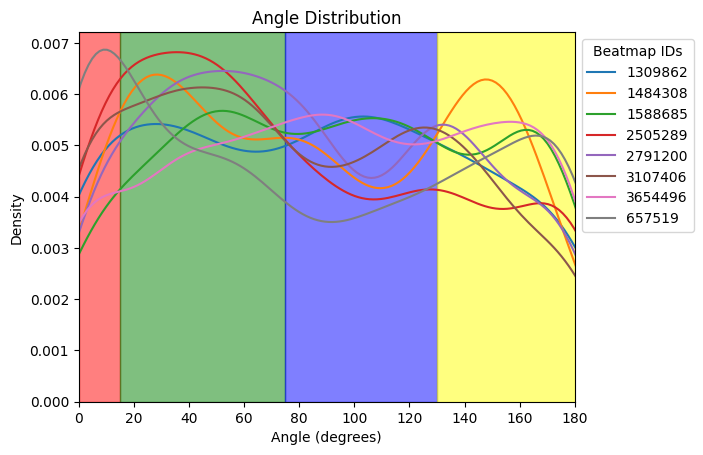

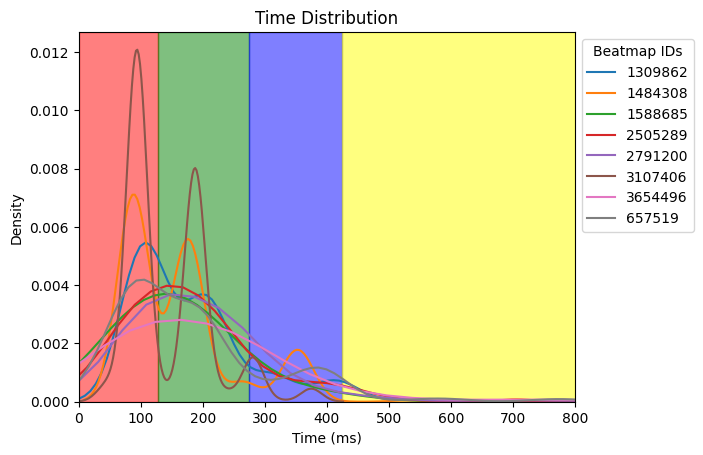

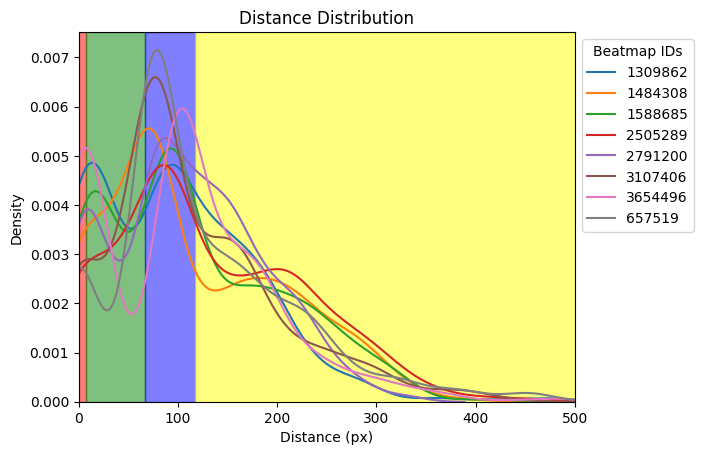

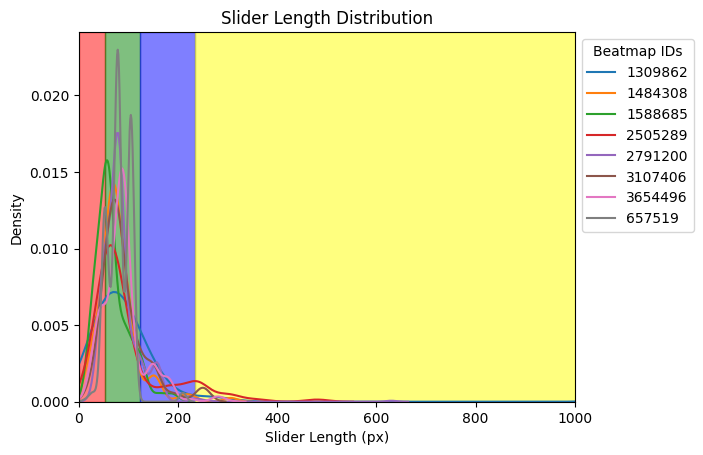

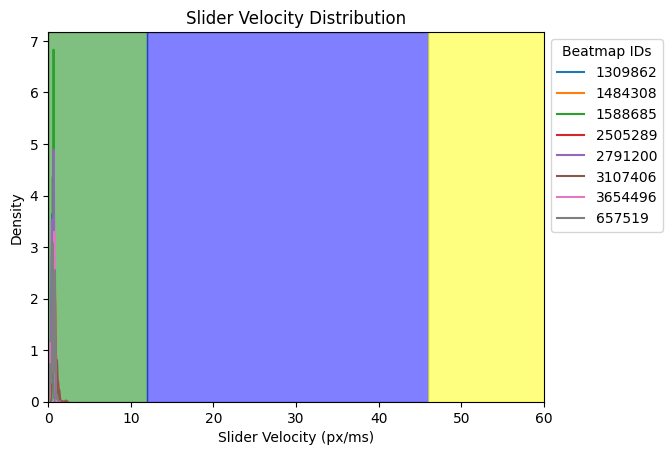

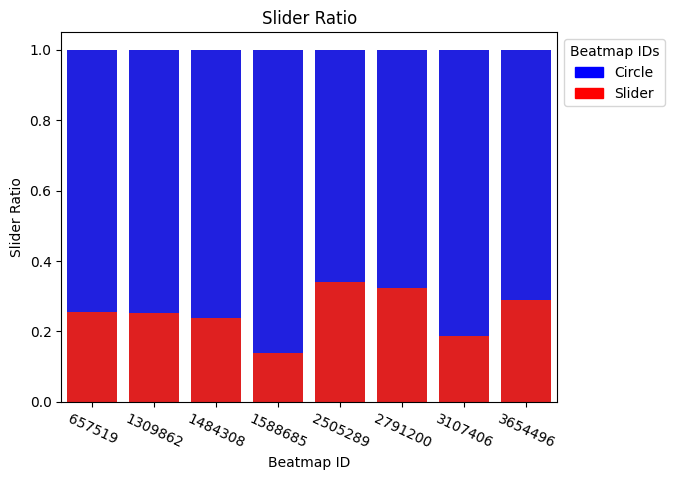

In [11]:
angle_breaks = [15, 75, 130]
time_breaks = [128, 275, 424]
distance_breaks = [7, 67, 117]
angle_lists = []
time_lists = []
distance_lists = []
for beatmap in cluster_beatmaps:
    with open(f"../dists/{beatmap}.dist") as f:
        angles = []
        times = []
        distances = []
        for line in f:
            if not line.strip():
                continue
            line = line.strip().split(',')
            angles.append(float(line[0]))
            times.append(float(line[1]))
            distances.append(float(line[2]))
        angle_lists.append(angles)
        time_lists.append(times)
        distance_lists.append(distances)

for angle in angle_lists:
    sns.kdeplot(angle)
plt.legend(cluster_beatmaps, title="Beatmap IDs", loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Angle Distribution")
plt.xlabel("Angle (degrees)")
plt.ylabel("Density")
# Set the x-axis range to be from 0 to 180.
plt.xlim(0, 180)
plt.axvspan(0, angle_breaks[0], alpha=0.5, color='red')
plt.axvspan(angle_breaks[0], angle_breaks[1], alpha=0.5, color='green')
plt.axvspan(angle_breaks[1], angle_breaks[2], alpha=0.5, color='blue')
plt.axvspan(angle_breaks[2], 180, alpha=0.5, color='yellow')
plt.show()

for time in time_lists:
    sns.kdeplot(time)
plt.legend(cluster_beatmaps, title="Beatmap IDs", loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Time Distribution")
plt.xlabel("Time (ms)")
plt.ylabel("Density")
plt.xlim(0, 800)
plt.axvspan(0, time_breaks[0], alpha=0.5, color='red')
plt.axvspan(time_breaks[0], time_breaks[1], alpha=0.5, color='green')
plt.axvspan(time_breaks[1], time_breaks[2], alpha=0.5, color='blue')
plt.axvspan(time_breaks[2], 800, alpha=0.5, color='yellow')
plt.show()

for distance in distance_lists:
    sns.kdeplot(distance)
plt.legend(cluster_beatmaps, title="Beatmap IDs", loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Distance Distribution")
plt.xlabel("Distance (px)")
plt.ylabel("Density")
plt.xlim(0, 500)
plt.axvspan(0, distance_breaks[0], alpha=0.5, color='red')
plt.axvspan(distance_breaks[0], distance_breaks[1], alpha=0.5, color='green')
plt.axvspan(distance_breaks[1], distance_breaks[2], alpha=0.5, color='blue')
plt.axvspan(distance_breaks[2], 500, alpha=0.5, color='yellow')
plt.show()

slider_length_breaks = [53, 123, 235]
slider_velocity_breaks = [0, 12, 46]
slider_length_lists = []
slider_velocity_lists = []
slider_ratio_list = []
for beatmap in cluster_beatmaps:
    with open(f"../sliders/{beatmap}.sldr") as f:
        slider_lengths = []
        slider_velocities = []
        for line in f:
            if not line.strip():
                continue
            line = line.strip().split(',')
            if len(line) != 2:
                slider_ratio_list.append(float(line[0]))
                continue
            slider_lengths.append(float(line[0]))
            slider_velocities.append(float(line[1]))
        slider_length_lists.append(slider_lengths)
        slider_velocity_lists.append(slider_velocities)

for slider_length in slider_length_lists:
    sns.kdeplot(slider_length)
plt.legend(cluster_beatmaps, title="Beatmap IDs", loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Slider Length Distribution")
plt.xlabel("Slider Length (px)")
plt.ylabel("Density")
plt.xlim(0, 1000)
plt.axvspan(0, slider_length_breaks[0], alpha=0.5, color='red')
plt.axvspan(slider_length_breaks[0], slider_length_breaks[1], alpha=0.5, color='green')
plt.axvspan(slider_length_breaks[1], slider_length_breaks[2], alpha=0.5, color='blue')
plt.axvspan(slider_length_breaks[2], 1000, alpha=0.5, color='yellow')
plt.show()

for slider_velocity in slider_velocity_lists:
    sns.kdeplot(slider_velocity)
plt.legend(cluster_beatmaps, title="Beatmap IDs", loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Slider Velocity Distribution")
plt.xlabel("Slider Velocity (px/ms)")
plt.ylabel("Density")
plt.xlim(0, 60)
plt.axvspan(0, slider_velocity_breaks[0], alpha=0.5, color='red')
plt.axvspan(slider_velocity_breaks[0], slider_velocity_breaks[1], alpha=0.5, color='green')
plt.axvspan(slider_velocity_breaks[1], slider_velocity_breaks[2], alpha=0.5, color='blue')
plt.axvspan(slider_velocity_breaks[2], 60, alpha=0.5, color='yellow')
plt.show()

# Create a bar plot of the slider ratios.
# Make a barplot where the y data is all 1's.
bar1 = sns.barplot(x=cluster_beatmaps, y=[1 for i in range(len(cluster_beatmaps))], color='blue')
bar2 = sns.barplot(x=cluster_beatmaps, y=slider_ratio_list, color='red')
top_bar = mpatches.Patch(color='blue', label='Circle')
bottom_bar = mpatches.Patch(color='red', label='Slider')
plt.legend(handles=[top_bar, bottom_bar], title="Beatmap IDs", loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Slider Ratio")
plt.xlabel("Beatmap ID")
plt.ylabel("Slider Ratio")
# Rotate the x-axis labels by 90 degrees.
plt.xticks(rotation=-25)
plt.show()

In [64]:
pca_2 = PCA(n_components=2)
pca_2_result = pca_2.fit_transform(df)
print('Explained variation per principal component: {}'.format(pca_2.explained_variance_ratio_))
print('Cumulative variance explained by 2 principal components: {:.2%}'.format(np.sum(pca_2.explained_variance_ratio_)))

# Results from pca.components_
dataset_pca = pd.DataFrame(abs(pca_2.components_), columns=df.columns, index=['PC_1', 'PC_2'])
print('\n\n', dataset_pca)

print("\n*************** Most important features *************************")
print('As per PC 1:\n', (dataset_pca[dataset_pca > 0.3].iloc[0]).dropna())
print('\n\nAs per PC 2:\n', (dataset_pca[dataset_pca > 0.3].iloc[1]).dropna())
print("\n******************************************************************")

Explained variation per principal component: [0.28912224 0.168683  ]
Cumulative variance explained by 2 principal components: 45.78%


        Angle_0   Angle_1   Angle_2   Angle_3    Time_0    Time_1    Time_2  \
PC_1  0.070957  0.224803  0.239857  0.055904  0.286710  0.423352  0.015943   
PC_2  0.034475  0.336443  0.078658  0.292260  0.235001  0.072138  0.003358   

        Time_3  Distance_0  Distance_1  ...  Distance_3    SRatio  SLength_0  \
PC_1  0.694118    0.041649    0.155589  ...    0.096962  0.048271   0.101932   
PC_2  0.159505    0.036633    0.260803  ...    0.563332  0.130703   0.258167   

      SLength_1  SLength_2  SLength_3  SVelocity_0  SVelocity_1  SVelocity_2  \
PC_1   0.014172   0.068487   0.022324     0.000605     0.010503     0.013053   
PC_2   0.142915   0.378795   0.028682     0.003568     0.039247     0.026454   

      SVelocity_3  
PC_1     0.000102  
PC_2     0.002830  

[2 rows x 21 columns]

*************** Most important features ***********************

Parameter: {'n_clusters': 3} Score 0.17468392231385627
Parameter: {'n_clusters': 7} Score 0.1398471106045126
Parameter: {'n_clusters': 15} Score 0.14226229004853239
Parameter: {'n_clusters': 38} Score 0.11418167152990345
Parameter: {'n_clusters': 77} Score 0.10372605700463272
Parameter: {'n_clusters': 155} Score 0.08997948823196371
Parameter: {'n_clusters': 775} Score 0.0768228213239823
Parameter: {'n_clusters': 1551} Score 0.0755694634499048
Parameter: {'n_clusters': 3102} Score 0.07538491570536696
Parameter: {'n_clusters': 7755} Score 0.07944960625895633
Parameter: {'n_clusters': 15511} Score 0.08112015212364349


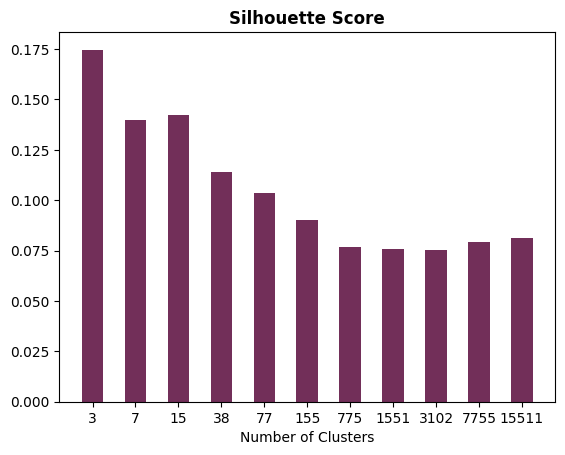

In [65]:
parameters = [3, 7, 15, 38, 77, 155, 775, 1551, 3102, 7755, 15511]

# instantiating ParameterGrid, pass number of clusters as input
parameter_grid = ParameterGrid({'n_clusters': parameters})

best_score = -1
kmeans_model = KMeans(init='k-means++', n_init='auto', random_state=42)
silhouette_scores = []

# evaluation based on silhouette_score
for p in parameter_grid:
    kmeans_model.set_params(**p)    # set current hyper parameter
    kmeans_model.fit(df)          # fit model on wine dataset, this will find clusters based on parameter p

    ss = metrics.silhouette_score(df, kmeans_model.labels_)   # calculate silhouette_score
    silhouette_scores += [ss]       # store all the scores

    print('Parameter:', p, 'Score', ss)

    # check p which has the best score
    if ss > best_score:
        best_score = ss
        best_grid = p

# plotting silhouette score
plt.bar(range(len(silhouette_scores)), list(silhouette_scores), align='center', color='#722f59', width=0.5)
plt.xticks(range(len(silhouette_scores)), list(parameters))
plt.title('Silhouette Score', fontweight='bold')
plt.xlabel('Number of Clusters')
plt.show()